# Predictive Maintenance - Tool Wear Failure

This notebook is an appendix of the main notebbok, which our multimodel failed to predict this kind of failure.
So, this will be a notebook to provide insights and find ways to describe a way to predict it.

In [227]:
import pandas as pd
import zipfile
import numpy as np
import io
import os
import requests
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, make_scorer
)
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE,SVMSMOTE,RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import optuna

In [2]:
URL = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(URL, headers=headers)

In [218]:
zip_buffer = io.BytesIO(response.content)
with zipfile.ZipFile(zip_buffer) as z:     
    csv_files = z.namelist()
    print(f"Arquivos encontrados: {csv_files}")
    f = z.open(csv_files[0])
    print(f"Carregando: {f}...")
    df = pl.read_csv(f)

Arquivos encontrados: ['ai4i2020.csv']
Carregando: <zipfile.ZipExtFile name='ai4i2020.csv' mode='r'>...


In [219]:
df = df.with_columns(TorqueWear = pl.col('Torque [Nm]')*pl.col('Tool wear [min]'))
df = df.with_columns(AirProcessTemperature = pl.col('Air temperature [K]')-pl.col('Process temperature [K]'))
df = df.with_columns(TorqueRPM = pl.col('Torque [Nm]')*pl.col('Rotational speed [rpm]'))


In [220]:
x = df.select(['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Tool wear [min]','Type','TorqueWear','AirProcessTemperature','TorqueRPM'])
y = df.select('TWF')
X = x.to_pandas()
Y = y.to_pandas()

<Axes: >

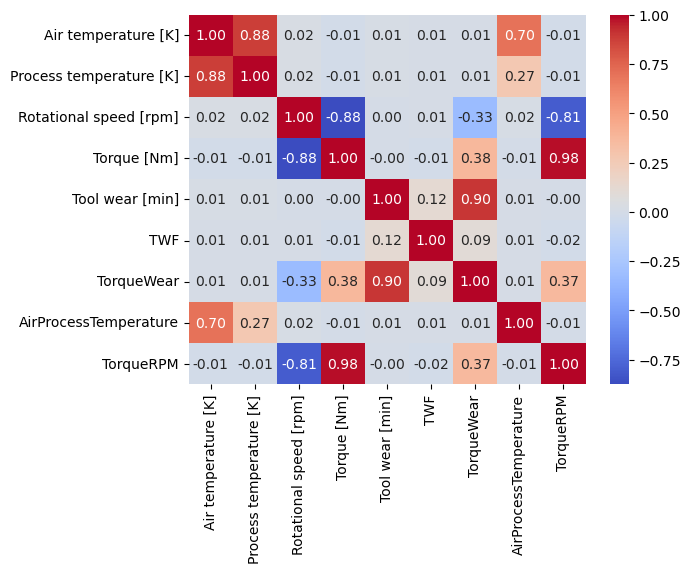

In [117]:
sns.heatmap(df.to_pandas().drop(columns = ['UDI','HDF','Machine failure','PWF','OSF','RNF']).select_dtypes(include='number').corr(),annot=True, fmt='.2f', cmap='coolwarm')

In [118]:
X.columns.tolist()

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Tool wear [min]',
 'Type',
 'TorqueWear',
 'AirProcessTemperature',
 'TorqueRPM']

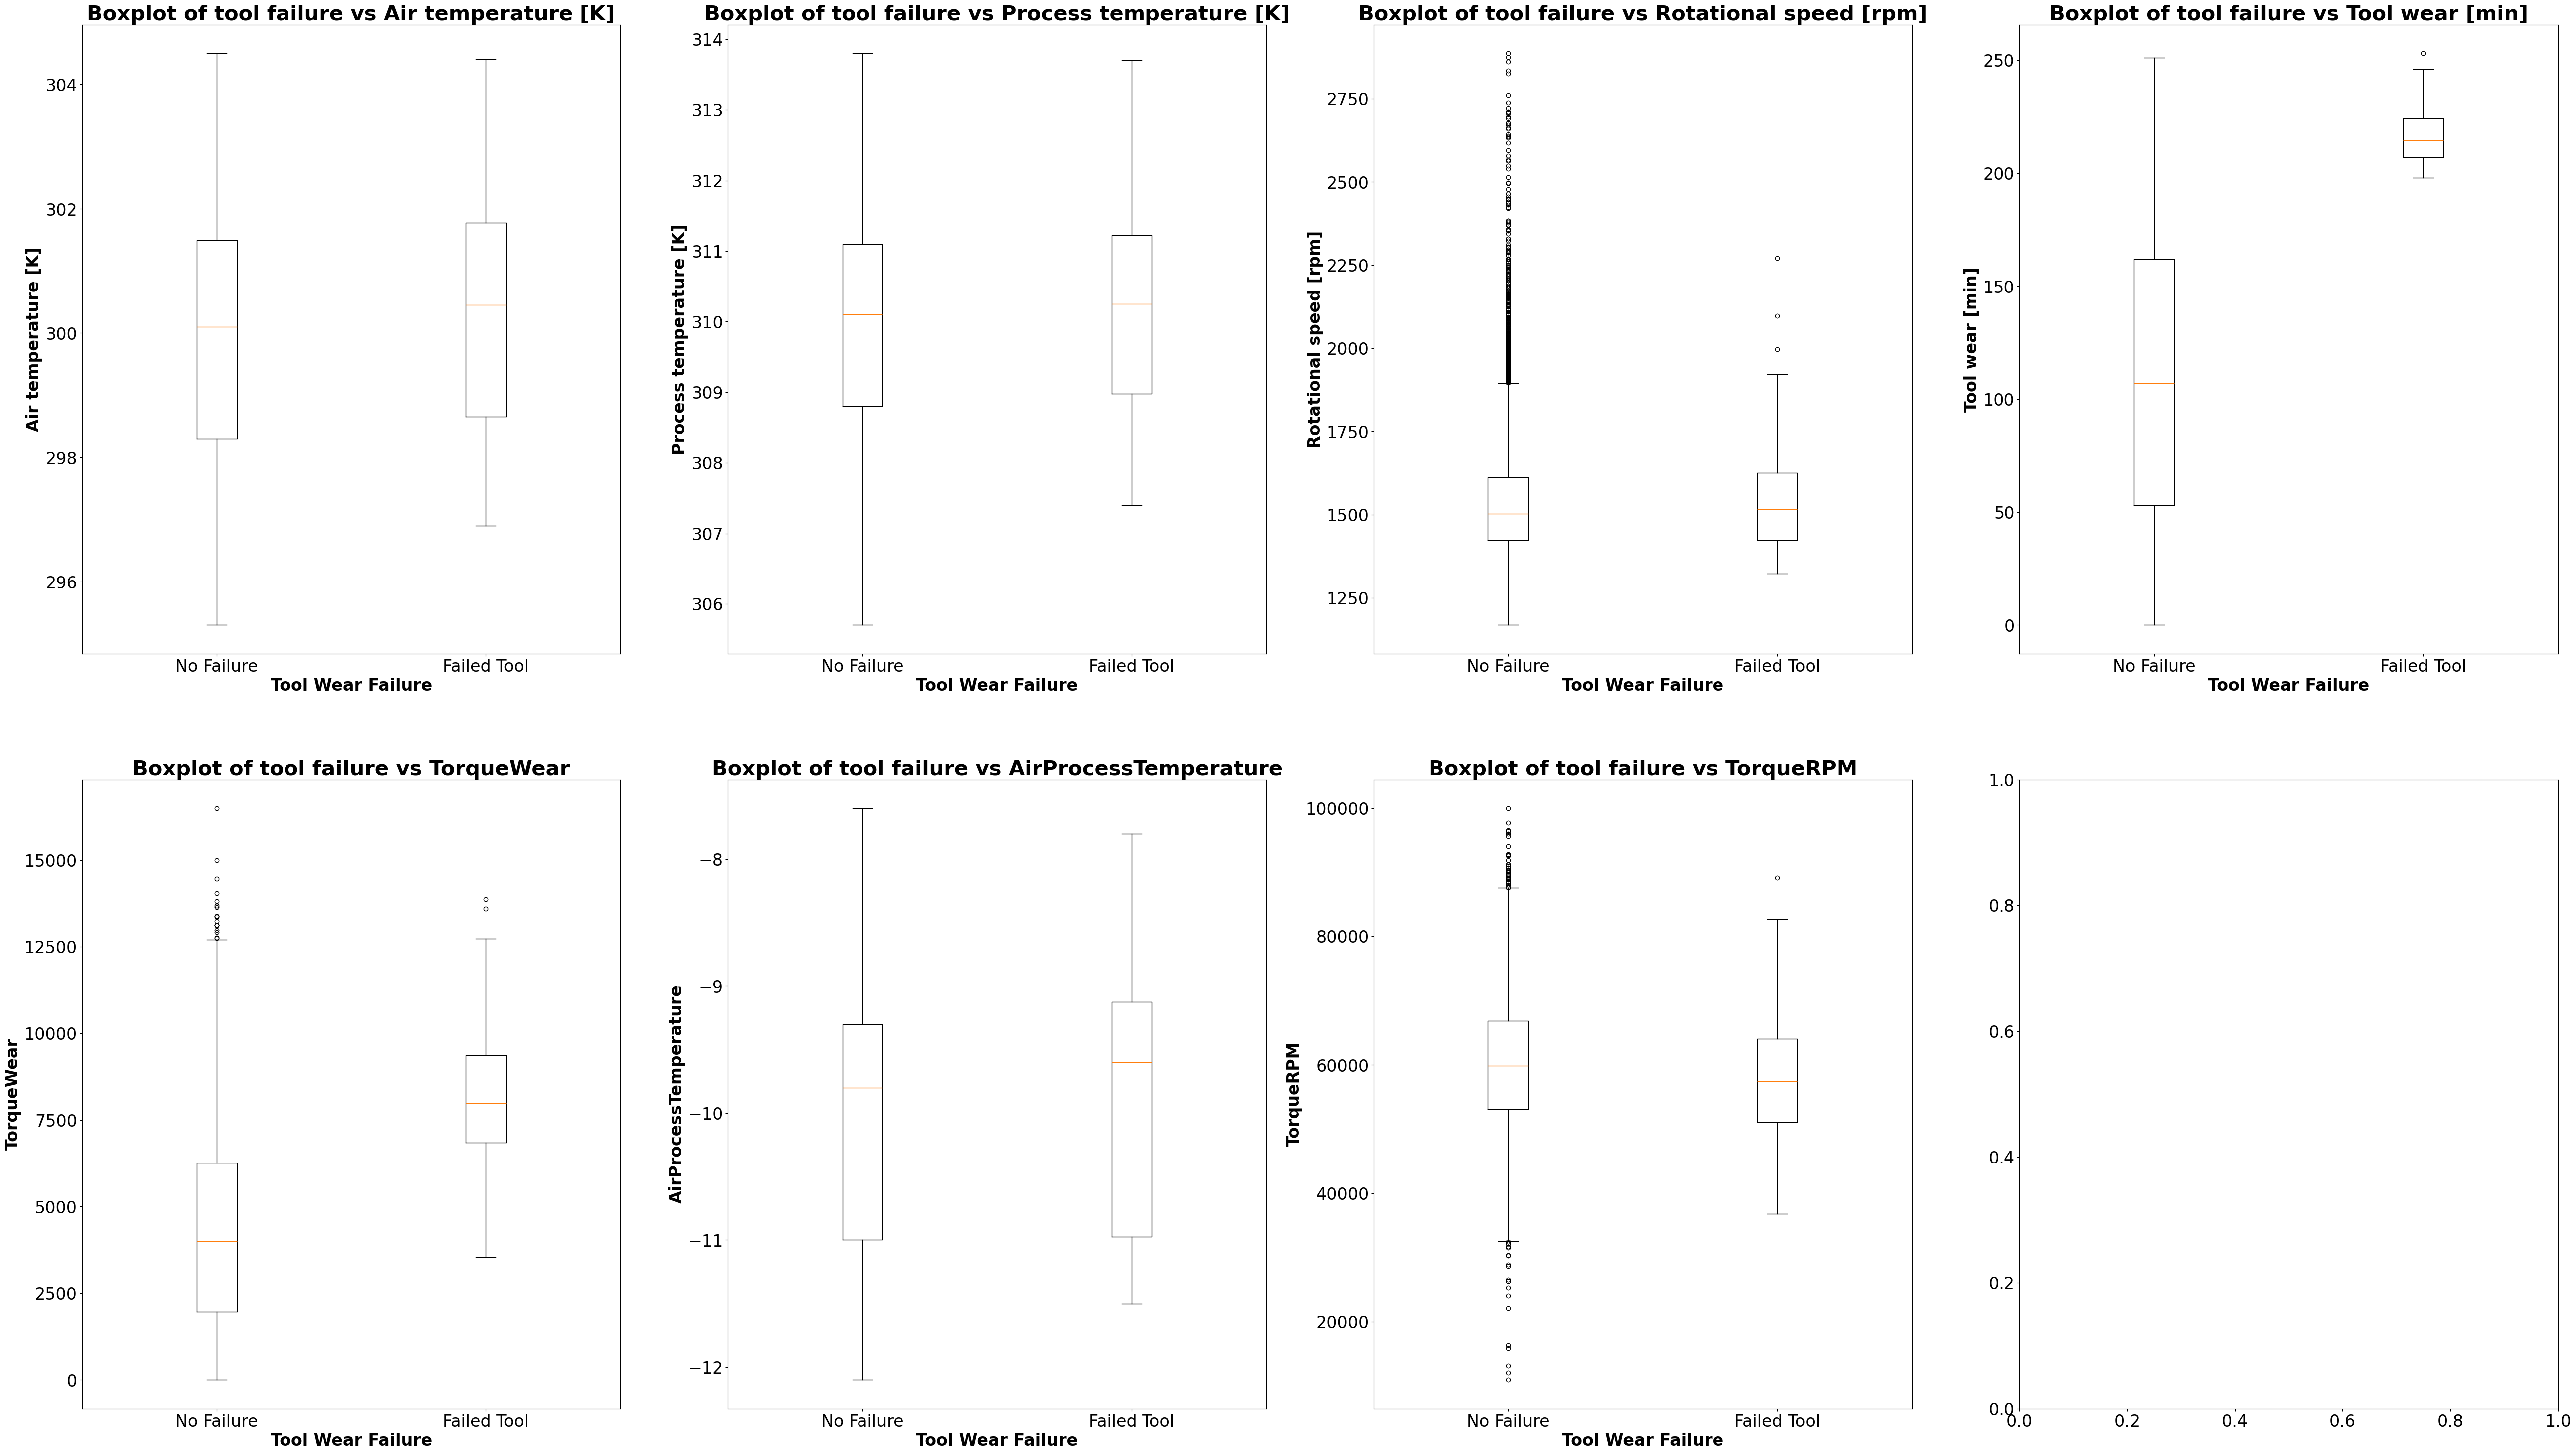

In [135]:
groups = df['TWF'].unique().sort().to_list()
fig, ax = plt.subplots(2,4,figsize=(64,36))

plt.rcParams['xtick.labelsize'] = 24
plt.rcParams['ytick.labelsize'] = 24

for i,feature in enumerate(X.drop(columns = ['Type']).columns.tolist()):

    dados = [df.filter(pl.col('TWF') == k)[feature].to_numpy() for k in groups]
    
    if i<4:
        ax[0][i].boxplot(dados, labels = groups)
        ax[0][i].set_title(f'Boxplot of tool failure vs {feature}',fontdict={'fontsize': 30, 'fontweight': 'bold'})
        ax[0][i].set_xlabel('Tool Wear Failure',fontdict={'fontsize': 24, 'fontweight': 'bold'})
        ax[0][i].set_ylabel(feature,fontdict={'fontsize': 24, 'fontweight': 'bold'})
        #ax[1].set_xticks([0, 1])
        ax[0][i].set_xticklabels(['No Failure', 'Failed Tool'])

    else:
        ax[1][i-4].boxplot(dados, labels = groups)
        ax[1][i-4].set_title(f'Boxplot of tool failure vs {feature}',fontdict={'fontsize': 30, 'fontweight': 'bold'})
        ax[1][i-4].set_xlabel('Tool Wear Failure',fontdict={'fontsize': 24, 'fontweight': 'bold'})
        ax[1][i-4].set_ylabel(feature,fontdict={'fontsize': 24, 'fontweight': 'bold'})
        #ax[1].set_xticks([0, 1])
        ax[1][i-4].set_xticklabels(['No Failure', 'Failed Tool'])
        

fig.show()   
    
    

From our boxplot, it seems that our TWF are just sensitive to our Tool Wear, and a little less with TorqueWear features. It makes sense, since our correlation matrix shows that only Tool Wear had a correlation over 0.1 (Which is still very low). Maybe this is an indicator of possible failure reason. From other variables, no other TWF relevant characteristic was seen.

Some outliars is seen within rotational speed and features related to it. Maybe it is a sign as well of possible failure, but this will be checked in a second moment.

For now, let's try a logistic regression to see what happens:

In [222]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pipelines_resultados = {}
#pipelines_resultados = {'Header':['Pipeline','Pipeline fit','Pipeline predict','Cross Score','Test Score','Confusion Matrix']} #dictionary to save our models and compare later

import warnings
warnings.filterwarnings('ignore')

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42,stratify = Y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

# ====================== define Preprocessor ===========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)])

# ======================= Define Oversampler =======================================
        
sampler = SMOTE(sampling_strategy = 0.1,random_state=42)
        

# ================================== Define Classifier ==============================

classifier = LogisticRegression(penalty = 'l1', C = 43.8752, solver = 'liblinear', max_iter = 1000)
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    ('Classifier',classifier)
])

pipelines_resultados['LR_1'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

# Logistic Regression Optimization - Optuna

In [106]:
def objective(trial):

    C =     trial.suggest_float('C', 1e-3, 100, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    
    samplers = [
    ("no_sampler", None),  # baseline sem oversampling
    ("random", RandomOverSampler(
        sampling_strategy=0.1,
        random_state=42
    )),
    ("smote", SMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,        # conservador com poucos dados
        random_state=42
    )),
    ("borderline", BorderlineSMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,
        random_state=42
    )),
    ("svmsmote", SVMSMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,
        random_state=42
    )),
    ("balanced_weight", None),
    ]

    sampler_name = trial.suggest_categorical(
        'samplers', ['no_sampler','random','smote', 'borderline','svmsmote','balanced_weight'])

    samplers_dict = dict(samplers)
    sampler_obj = samplers_dict[sampler_name]
    
    use_class_weight = "balanced" if sampler_name == "balanced_weight" else None
        
    # Monta o pipeline com os parâmetros sugeridos
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', sampler_obj),
        ('classifier', LogisticRegression(
            penalty = 'elasticnet',
            C = C,
            solver = 'saga',
            l1_ratio=l1_ratio,
            max_iter = 1000,
            random_state=42,
            class_weight=use_class_weight
        ))
    ])

    # Cross-validation estratificado — mantém proporção das classes
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, x_train, y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1
    )

    return scores.mean()


In [107]:
sampler_optuna  = optuna.samplers.TPESampler(seed=42)   # Bayesiano
pruner_optuna   = optuna.pruners.MedianPruner()         # Poda tentativas ruins

study = optuna.create_study(
    direction='maximize',           # Queremos maximizar o score
    sampler=sampler_optuna,
    pruner=pruner_optuna
)

# n_trials = número de combinações testadas
# 100 tentativas já costuma convergir bem para XGBoost
study.optimize(objective, n_trials=500, show_progress_bar=True)


[I 2026-03-06 11:20:35,430] A new study created in memory with name: no-name-ad581fbc-29aa-4ebc-8b7a-480e408c21ed
Best trial: 0. Best value: 0.185772:   0%|          | 1/500 [00:09<1:21:33,  9.81s/it]

[I 2026-03-06 11:20:45,235] Trial 0 finished with value: 0.1857717525439514 and parameters: {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162, 'samplers': 'balanced_weight'}. Best is trial 0 with value: 0.1857717525439514.


Best trial: 1. Best value: 0.198872:   0%|          | 2/500 [00:10<36:09,  4.36s/it]  

[I 2026-03-06 11:20:45,774] Trial 1 finished with value: 0.198871819315536 and parameters: {'C': 1.0129197956845732, 'l1_ratio': 0.7080725777960455, 'samplers': 'random'}. Best is trial 1 with value: 0.198871819315536.


Best trial: 1. Best value: 0.198872:   1%|          | 3/500 [00:10<20:34,  2.48s/it]

...

[I 2026-03-06 11:31:22,667] Trial 497 finished with value: 0.2049459392558695 and parameters: {'C': 17.304971232069878, 'l1_ratio': 0.0925669692093012, 'samplers': 'balanced_weight'}. Best is trial 452 with value: 0.23163337289441438.


Best trial: 452. Best value: 0.231633: 100%|█████████▉| 499/500 [10:53<00:04,  4.69s/it]

[I 2026-03-06 11:31:28,540] Trial 498 finished with value: 0.21487223855601775 and parameters: {'C': 21.83291147793136, 'l1_ratio': 0.10578811931598711, 'samplers': 'balanced_weight'}. Best is trial 452 with value: 0.23163337289441438.


Best trial: 452. Best value: 0.231633: 100%|██████████| 500/500 [10:56<00:00,  1.31s/it]

[I 2026-03-06 11:31:32,095] Trial 499 finished with value: 0.1740766092572683 and parameters: {'C': 21.42129030792533, 'l1_ratio': 0.09920326044009564, 'samplers': 'balanced_weight'}. Best is trial 452 with value: 0.23163337289441438.


In [98]:
study.best_params

{'C': 0.0030258063819562776,
 'l1_ratio': 0.03739143904824192,
 'samplers': 'random'}

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

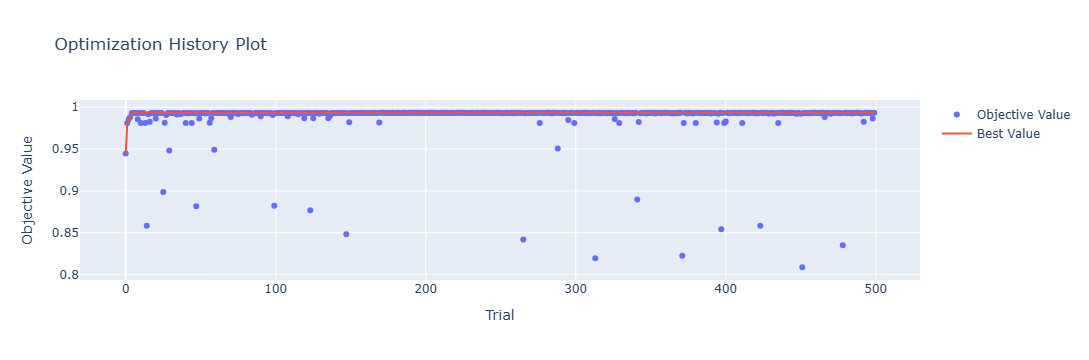

In [99]:
optuna.visualization.plot_optimization_history(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

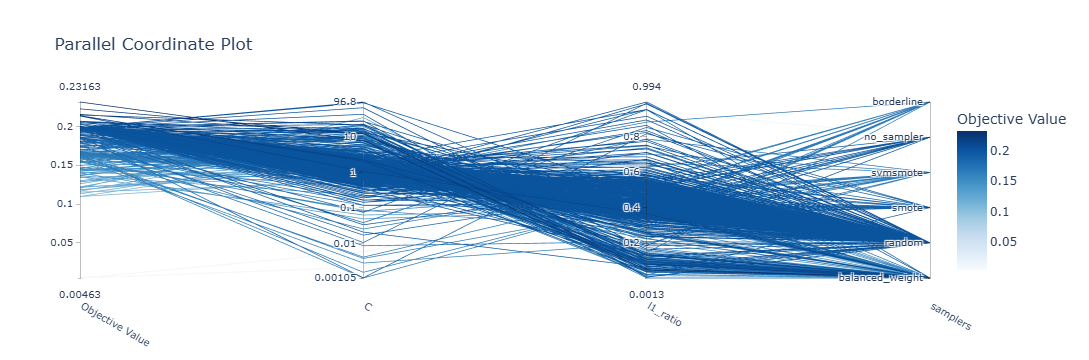

In [57]:
optuna.visualization.plot_parallel_coordinate(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

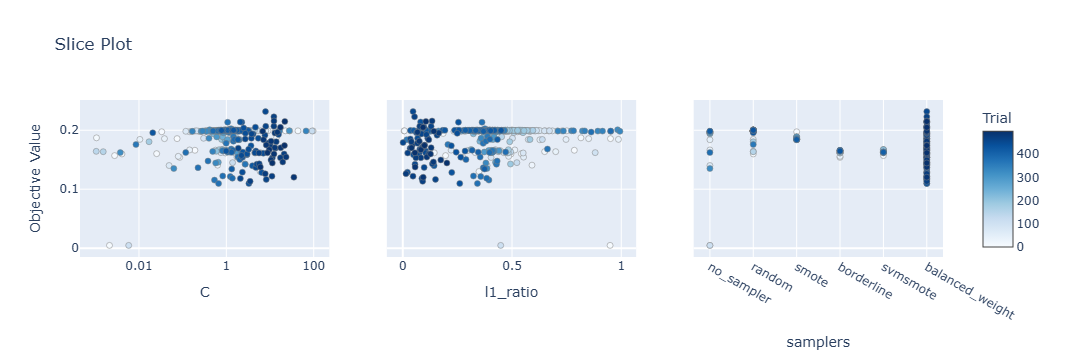

In [58]:
optuna.visualization.plot_slice(study,params = ['C','l1_ratio','samplers'])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

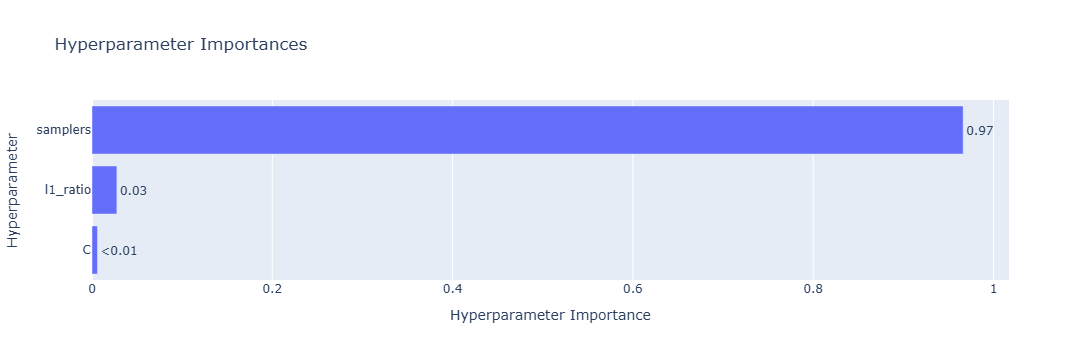

In [100]:
optuna.visualization.plot_param_importances(study)

# Next Steps - Logistic Regression comparison

In [108]:
print(dict(samplers)[study.best_params['samplers']])

None


In [223]:
sampler = dict(samplers)[study.best_params['samplers']]
balanced_weight = None if sampler != None else 'balanced'
        

# ================================== Define Classifier ==============================

classifier = LogisticRegression(penalty = 'elasticnet', C = study.best_params['C'], solver = 'saga',l1_ratio = study.best_params['l1_ratio'],class_weight = balanced_weight, max_iter = 1000)
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    ('Classifier',classifier)])



pipelines_resultados['LR_Optimized'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

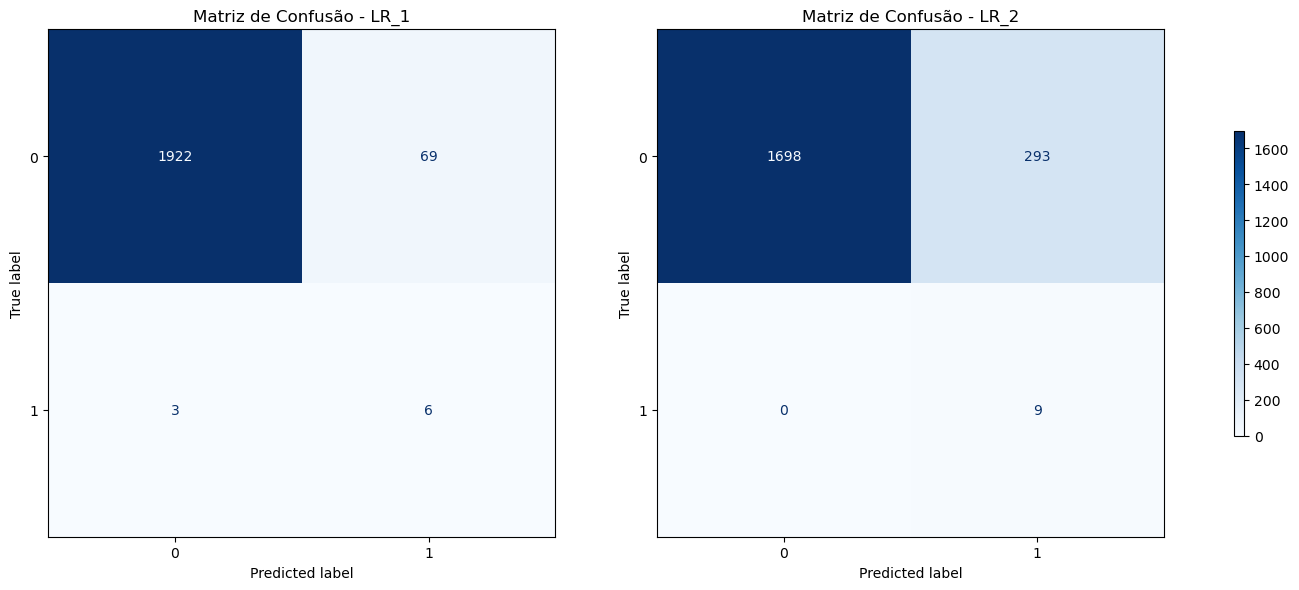

In [110]:
fig,ax = plt.subplots(1,2 , figsize = (18,12))
images = []

for i,k in enumerate(pipelines_resultados):
    disp = ConfusionMatrixDisplay(confusion_matrix = pipelines_resultados[k][-1])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {k}')
    #ax[i].set_xticklabels(rotation = 45)
    #ax[i].set_yticklabels(rotation = 60)
    images.append(ax[i].images[0])
    
fig.colorbar(images[-1], ax=ax, location='right', shrink=0.33, aspect = 30)
    

## Logistic regression analysis

Our optimized model performed worse than our baseline model, due to the high amount of false positives. There was no false negatives in the optmized one.

If a failure by Tool Wear is way more expensive than just to stop and change the tool for our machine, the LR_Optimized could be a better choice. Otherwise, the high number of false positives in both models does not justify using it for now.

# Data Cleaning and Feature Engineering

As seen in the boxplot, there were many outliars in the rotational speed boxplot. Let's see if it somehow affects our predictions:

In [224]:
df_pd = df.to_pandas()
df_pd = df_pd.drop(columns = ['UDI','Product ID','Machine failure','HDF','PWF','OSF','RNF'])

Q1 = df_pd[df_pd['TWF'] == 0]['Rotational speed [rpm]'].quantile(0.25)
Q3 = df_pd[df_pd['TWF'] == 0]['Rotational speed [rpm]'].quantile(0.75)
 #=====================
IQR = Q3-Q1

df_pd = df_pd[(df_pd['TWF'] != 0 )|(df_pd['TWF'] == 0) & (df_pd['Rotational speed [rpm]'] >= (Q1 - 1.5*IQR)) & (df_pd['Rotational speed [rpm]'] <= (Q3 + 1.5*IQR))] 
df_pd = df_pd.reset_index(drop=True)
print(f'New df format:{df_pd.shape}')

X = df_pd.drop(columns = 'TWF')
Y = df_pd[['TWF']]


New df format:(9586, 10)


In [225]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42,stratify = Y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

# ====================== define Preprocessor ===========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)])

# ======================= Define Oversampler =======================================
        
sampler = SMOTE(sampling_strategy = 0.1,random_state=42)
        

# ================================== Define Classifier ==============================

classifier = LogisticRegression(penalty = 'l1', C = 43.8752, solver = 'liblinear', max_iter = 1000)
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    ('Classifier',classifier)
])

pipelines_resultados['LR_2'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

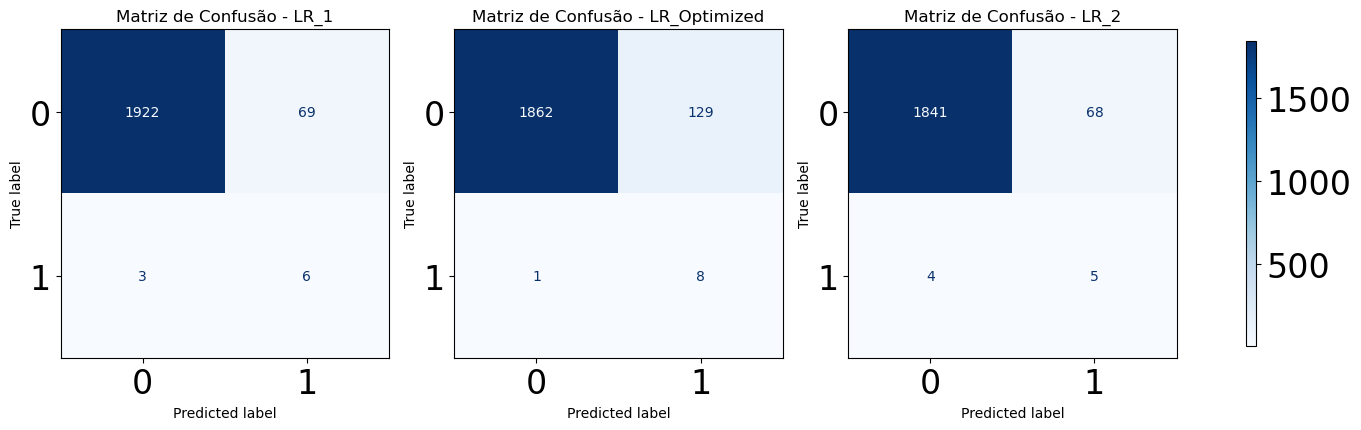

In [226]:
fig,ax = plt.subplots(1,3 , figsize = (18,12))
images = []

for i,k in enumerate(pipelines_resultados):
    disp = ConfusionMatrixDisplay(confusion_matrix = pipelines_resultados[k][-1])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {k}')
    #ax[i].set_xticklabels(rotation = 45)
    #ax[i].set_yticklabels(rotation = 60)
    images.append(ax[i].images[0])
    
fig.colorbar(images[-1], ax=ax, location='right', shrink=0.33, aspect = 30)

So, our outliers removal did not yield great results. So, let's try another approach:

## POLYNOMIAL FEAFURES + PCA

In [228]:
features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

# ====================== define Preprocessor ===========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)])

# ======================= Define Oversampler =======================================
        
sampler = SMOTE(sampling_strategy = 0.1,random_state=42)
        

# ================================== Define Classifier ==============================

classifier = LogisticRegression(penalty = 'l1', C = 43.8752, solver = 'liblinear', max_iter = 1000)
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    ('Poly',PolynomialFeatures(degree=2,include_bias=False)),
    ('Classifier',classifier)
])

pipelines_resultados['LR_Poly'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

In [229]:
features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

# ====================== define Preprocessor ===========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)])

# ======================= Define Oversampler =======================================
        
sampler = SMOTE(sampling_strategy = 0.1,random_state=42)
        

# ================================== Define Classifier ==============================

classifier = LogisticRegression(penalty = 'l1', C = 43.8752, solver = 'liblinear', max_iter = 1000)
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    ('Poly',PolynomialFeatures(degree=2,include_bias=False)),
    ('PCA',PCA(n_components=0.95)),
    ('Classifier',classifier)
])

pipelines_resultados['LR_Poly_PCA'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

## Last shot - RandomForestRegressor

In [230]:
features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

# ====================== define Preprocessor ===========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)])

# ======================= Define Oversampler =======================================
        
sampler = SMOTE(sampling_strategy = 0.1,random_state=42)
        

# ================================== Define Classifier ==============================

classifier = RandomForestClassifier(
        n_estimators = 329,
        max_depth = 29,
        min_samples_split = 3,
        min_samples_leaf = 2,
        max_features = 'log2',
        class_weight = None
    )
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    #('Poly',PolynomialFeatures(degree=2,include_bias=False)),
    #('PCA',PCA(n_components=0.95)),
    ('Classifier',classifier)
])

pipelines_resultados['RFR'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

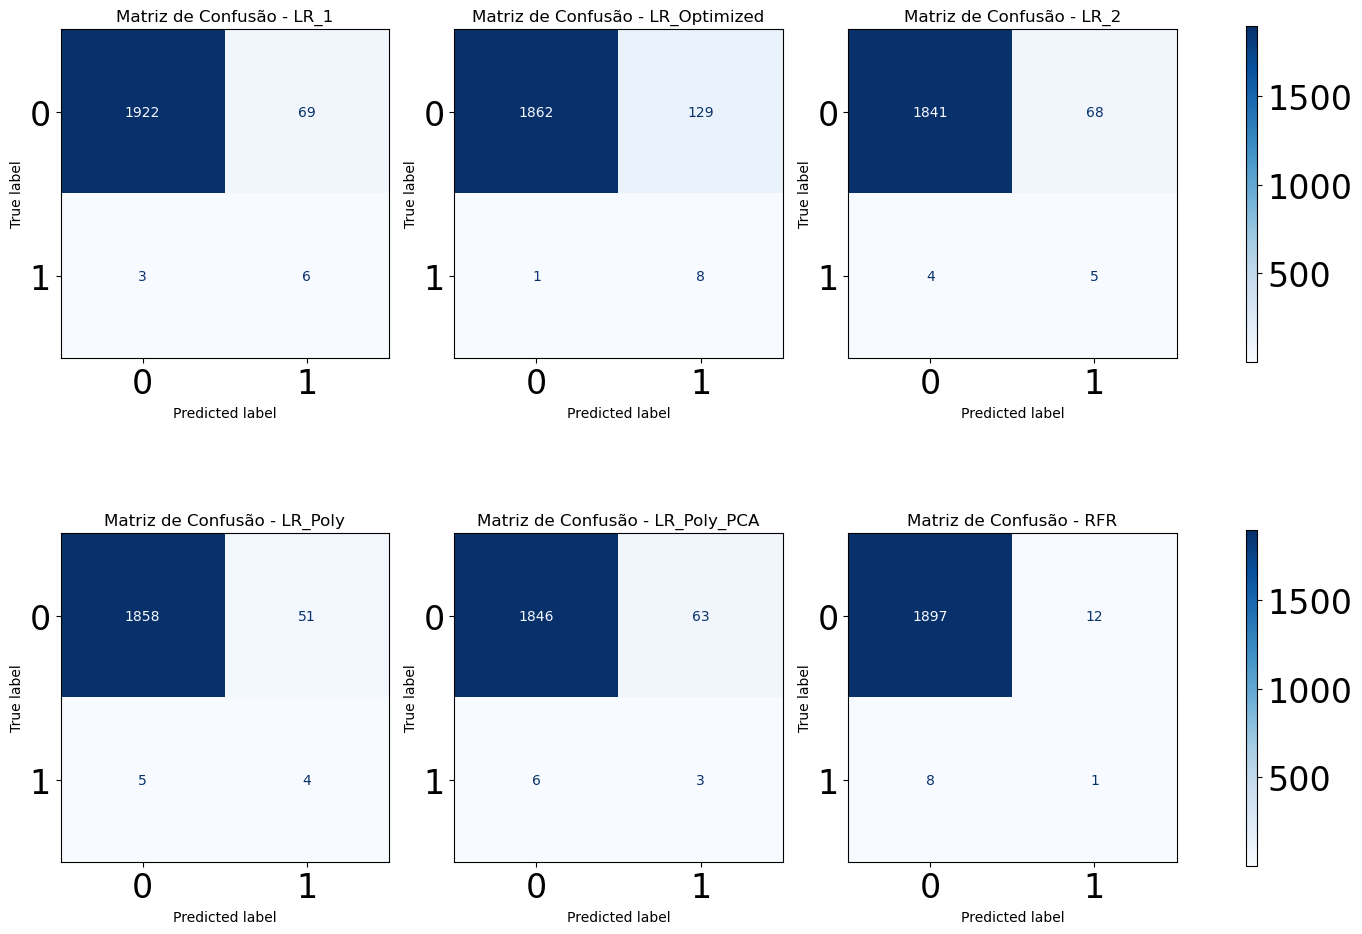

In [239]:
fig,ax = plt.subplots(2,3 , figsize = (18,12))
images = []

for i,k in enumerate(pipelines_resultados):
    if i < 3:
        disp = ConfusionMatrixDisplay(confusion_matrix = pipelines_resultados[k][-1])
        disp.plot(cmap='Blues', ax=ax[0][i], colorbar = False)
        ax[0][i].set_title(f'Matriz de Confusão - {k}')
    #ax[i].set_xticklabels(rotation = 45)
    #ax[i].set_yticklabels(rotation = 60)
        images.append(ax[0][i].images[0])
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix = pipelines_resultados[k][-1])
        disp.plot(cmap='Blues', ax=ax[1][i-3], colorbar = False)
        ax[1][i-3].set_title(f'Matriz de Confusão - {k}')
    #ax[i].set_xticklabels(rotation = 45)
    #ax[i].set_yticklabels(rotation = 60)
        images.append(ax[1][i-3].images[0])
    
fig.colorbar(images[-1], ax=ax[0], location='right', shrink=0.8, aspect = 30)
fig.colorbar(images[-1], ax=ax[1], location='right', shrink=0.8, aspect = 30)

So, comparing all our results of our Logistic Regressor, it was not even close to be good as our Random Forest Classifier, which also was not close to not having a predictor at all.

Only 9 Fails in the test sample, and our model cannot predict quite well. Let's see through our train/validation models how well they performed

In [263]:
for i,k in enumerate(pipelines_resultados):
    print(f"Classifier: {k} Validation score: {pipelines_resultados[k][3]['test_score'].mean():.3f}\nTrain score: {pipelines_resultados[k][3]['train_score'].mean():.3f}\n")

Classifier: LR_1 Validation score: 0.981
Train score: 0.981

Classifier: LR_Optimized Validation score: 0.952
Train score: 0.951

Classifier: LR_2 Validation score: 0.982
Train score: 0.983

Classifier: LR_Poly Validation score: 0.986
Train score: 0.990

Classifier: LR_Poly_PCA Validation score: 0.983
Train score: 0.984

Classifier: RFR Validation score: 0.990
Train score: 1.000



Let's also check their prediction performance numbers

In [245]:
for i,k in enumerate(pipelines_resultados):
    print(f'Classifier: {k} \n{pipelines_resultados[k][4]}')

Classifier: LR_1 
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1991
           1       0.08      0.67      0.14         9

    accuracy                           0.96      2000
   macro avg       0.54      0.82      0.56      2000
weighted avg       0.99      0.96      0.98      2000

Classifier: LR_Optimized 
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1991
           1       0.06      0.89      0.11         9

    accuracy                           0.94      2000
   macro avg       0.53      0.91      0.54      2000
weighted avg       1.00      0.94      0.96      2000

Classifier: LR_2 
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1909
           1       0.07      0.56      0.12         9

    accuracy                           0.96      1918
   macro avg       0.53      0.76      0.55      1918
weighted avg

# Conclusion

It is very hard for our models to predict this kind of failure, since they are very few, and they seem to be quite entangled with non failure cases within the process.

Actually, in the dataset description, it is said that many times the tool were changes before the machine fails. Maybe if the process is kept going until more failures happened, more data could be gathered and the predictor could actually have a better view of when it is about to happen.

It is important also to see if another kind of failure may happen before the 